Flow matching example, adapted from https://github.com/facebookresearch/flow_matching

In [9]:
import torch
from torch import nn, Tensor

import matplotlib.pyplot as plt
from sklearn.datasets import make_moons

# Toggle to display/save figures later on.
print_figs = True

# Device
device = torch.device("mps" if torch.backends.mps.is_available() else "cpu")
print(f"Using device: {device}")

# Set global plotting style for clearer lecture-note figures.
plt.rcParams.update({
    "axes.titlesize": 20,   # Title size for each subplot
    "axes.labelsize": 18,   # Axis label size
    "xtick.labelsize": 16,  # x-axis tick label size
    "ytick.labelsize": 16,  # y-axis tick label size
    "legend.fontsize": 14,  # Legend font size
    "lines.linewidth": 3,   # Default line width
})

Using device: mps


In [10]:
class Flow(nn.Module):
    def __init__(self, dim: int = 2, h: int = 64):
        super().__init__()

        # Neural network parametrizing the time-dependent velocity field v_theta(t, x_t).
        # Input dimension is dim + 1 because we concatenate:
        # - the scalar time t
        # - the spatial point x_t in R^dim
        #
        # For this example:
        # - dim = 2, since we work in the plane
        # - h = 64 is the hidden width
        self.net = nn.Sequential(
            nn.Linear(dim + 1, h),
            nn.ELU(),
            nn.Linear(h, h),
            nn.ELU(),
            nn.Linear(h, h),
            nn.ELU(),
            nn.Linear(h, dim),
        )

    def forward(self, t: Tensor, x_t: Tensor) -> Tensor:
        # Evaluate the learned vector field at time t and position x_t.
        #
        # Expected shapes:
        # - t   : (batch_size, 1)
        # - x_t : (batch_size, dim)
        #
        # Concatenating them along the last dimension gives shape:
        # - (batch_size, dim + 1)
        return self.net(torch.cat((t, x_t), dim=-1))

    def step(self, x_t: Tensor, t_start: Tensor, t_end: Tensor) -> Tensor:
        # Advance particles from t_start to t_end using a midpoint / RK2-style step.
        #
        # Inputs:
        # - x_t     : (batch_size, dim), current particle locations
        # - t_start : scalar tensor, start time
        # - t_end   : scalar tensor, end time
        #
        # We expand t_start so that it matches the batch dimension.
        t_start = t_start.view(1, 1).expand(x_t.shape[0], 1)

        # For robustness on MPS, it is often cleaner to also reshape/expand t_end
        # so that all operations happen with matching tensor shapes on the same device.
        t_end = t_end.view(1, 1).expand(x_t.shape[0], 1)

        dt = t_end - t_start

        # Midpoint method:
        # 1. Compute the velocity at the start of the interval
        v_start = self(t=t_start, x_t=x_t)

        # 2. Predict the midpoint in state and time
        t_mid = t_start + dt / 2
        x_mid = x_t + v_start * dt / 2

        # 3. Evaluate the velocity at the midpoint
        v_mid = self(t=t_mid, x_t=x_mid)

        # 4. Take the full step using the midpoint velocity
        return x_t + dt * v_mid

# Training

In [11]:
# Choose the computation device.
device = torch.device("mps" if torch.backends.mps.is_available() else "cpu")
print(f"Using device: {device}")

flow = Flow().to(device)
optimizer = torch.optim.Adam(flow.parameters(), lr=1e-2)
loss_fn = nn.MSELoss()

# Number of gradient steps.
n_train_steps = 10_000

# Optional: keep track of the training loss for later inspection.
loss_history = []

flow.train()
for step in range(n_train_steps):
    # Sample a minibatch from the target distribution q(x).
    # Here q is the two-moons dataset.
    #
    # make_moons returns NumPy arrays, so we convert the point cloud to a torch tensor
    # with dtype float32 and place it directly on the selected device.
    x_1 = torch.tensor(
        make_moons(256, noise=0.05)[0],
        dtype=torch.float32,
        device=device,
    )

    # Sample the source points x_0 from the standard Gaussian p(x) = N(0, I).
    # torch.randn_like ensures same shape, dtype, and device as x_1.
    x_0 = torch.randn_like(x_1)

    # Sample times uniformly in [0, 1], one per training example.
    t = torch.rand(len(x_1), 1, device=device)

    # Construct the rectified-flow interpolation:
    x_t = (1 - t) * x_0 + t * x_1

    # The target velocity field for this conditional path is constant in time:
    dx_t = x_1 - x_0

    # Standard optimization step.
    optimizer.zero_grad()

    # Predict the velocity with the neural network and compare it to the analytic target.
    pred = flow(t=t, x_t=x_t)
    loss = loss_fn(pred, dx_t)

    # Backpropagation and parameter update.
    loss.backward()
    optimizer.step()

    # Store the loss value for plotting/debugging.
    loss_history.append(loss.item())

    # Optional progress print every 1000 steps.
    if (step + 1) % 1000 == 0:
        print(f"Step {step + 1:5d}/{n_train_steps} | Loss = {loss.item():.6f}")

Using device: mps
Step  1000/10000 | Loss = 0.874244
Step  2000/10000 | Loss = 0.968427
Step  3000/10000 | Loss = 0.836596
Step  4000/10000 | Loss = 0.917927
Step  5000/10000 | Loss = 1.038409
Step  6000/10000 | Loss = 0.929302
Step  7000/10000 | Loss = 0.891907
Step  8000/10000 | Loss = 0.905421
Step  9000/10000 | Loss = 0.879177
Step 10000/10000 | Loss = 0.954178


# Sampling

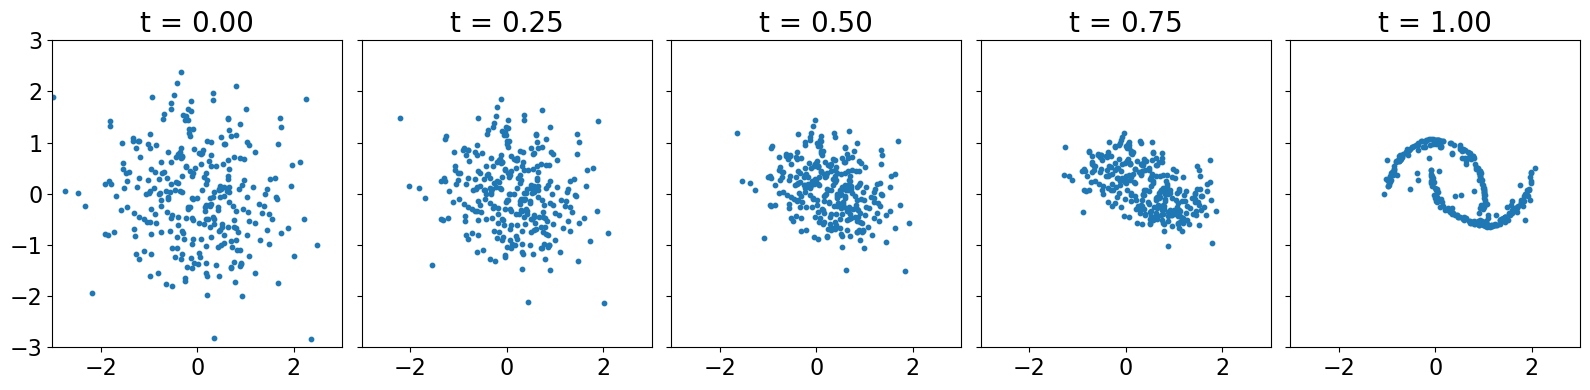

In [13]:
# Draw initial particles from the source distribution p(x) = N(0, I).
# These will be transported by the learned flow toward the target distribution.
x = torch.randn(300, 2, device=device)

# Number of numerical integration steps used to solve the learned ODE.
# We will visualize the particle locations at each intermediate time.
n_steps = 4

# Create a row of subplots showing the evolution of the particles.
fig, axes = plt.subplots(
    1, n_steps + 1,
    figsize=(16, 4),
    sharex=True,
    sharey=True
)

# Discretize the time interval [0,1].
# These define the integration grid for the ODE solver.
time_steps = torch.linspace(0, 1.0, n_steps + 1, device=device)

# Plot the initial distribution at t = 0.
# Matplotlib requires CPU tensors, so we move the data back from MPS.
axes[0].scatter(
    x.detach().cpu()[:, 0],
    x.detach().cpu()[:, 1],
    s=10
)

axes[0].set_title(f"t = {time_steps[0].item():.2f}")
axes[0].set_xlim(-3.0, 3.0)
axes[0].set_ylim(-3.0, 3.0)

# Disable gradient tracking during sampling / inference.
with torch.no_grad():

    # Sequentially integrate the learned ODE
    #    dx/dt = v_theta(t, x)
    # using the midpoint step implemented in flow.step().
    for i in range(n_steps):

        # Advance particles from t_i to t_{i+1}.
        x = flow.step(
            x_t=x,
            t_start=time_steps[i],
            t_end=time_steps[i + 1]
        )

        # Plot particle positions at the new time.
        axes[i + 1].scatter(
            x.detach().cpu()[:, 0],
            x.detach().cpu()[:, 1],
            s=10
        )

        axes[i + 1].set_title(f"t = {time_steps[i + 1].item():.2f}")

# Improve subplot spacing.
plt.tight_layout()

# Optionally save the figure for lecture notes.
if print_figs:
    plt.savefig(
        "../img/week8_flow_matching.pdf",
        format="pdf",
        bbox_inches="tight"
    )

# Show the figure interactively.
plt.show()